In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.feature_engineering import preprocess_data
from src.model import train_model

In [3]:
df = load_data()

df.head()
df.shape

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   loanid          255347 non-null  object 
 1   age             255347 non-null  int64  
 2   income          255347 non-null  int64  
 3   loanamount      255347 non-null  int64  
 4   creditscore     255347 non-null  int64  
 5   monthsemployed  255347 non-null  int64  
 6   numcreditlines  255347 non-null  int64  
 7   interestrate    255347 non-null  float64
 8   loanterm        255347 non-null  int64  
 9   dtiratio        255347 non-null  float64
 10  education       255347 non-null  object 
 11  employmenttype  255347 non-null  object 
 12  maritalstatus   255347 non-null  object 
 13  hasmortgage     255347 non-null  object 
 14  hasdependents   255347 non-null  object 
 15  loanpurpose     255347 non-null  object 
 16  hascosigner     255347 non-null  object 
 17  default   

In [4]:
df['default'].value_counts()

default
0    225694
1     29653
Name: count, dtype: int64

In [5]:
# Create X and y
X = df.drop('default', axis=1)
y = df['default']

# Keep only numeric columns (avoid memory issue)
X = X.select_dtypes(include=['int64','float64'])

# Scale data (IMPORTANT for Logistic Regression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Check shape
print("Shape after scaling:", X.shape)

Shape after scaling: (255347, 9)


In [6]:
model = train_model(X, y)

Accuracy: 0.6697865674564324
AUC-ROC: 0.7459811671913636


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6697865674564324
AUC-ROC: 0.7459811671913636
Confusion Matrix:
 [[30102 15068]
 [ 1796  4104]]


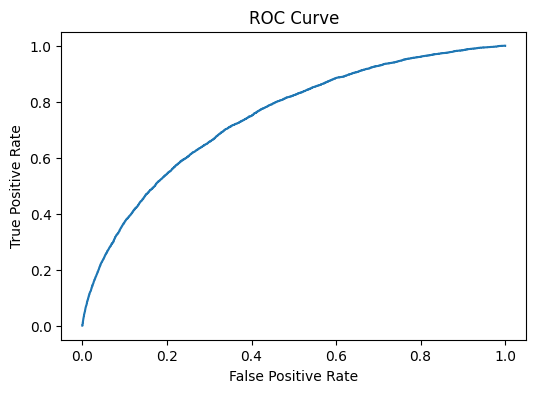

In [8]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [9]:
# Get feature names (numeric only)
feature_names = df.drop('default', axis=1) \
                  .select_dtypes(include=['int64','float64']) \
                  .columns

# Create importance
feature_importance = pd.Series(
    model.coef_[0],
    index=feature_names
)

# Top features
feature_importance.sort_values().tail(10)

age              -0.577518
monthsemployed   -0.333629
income           -0.310274
creditscore      -0.120023
loanterm         -0.005313
dtiratio          0.063485
numcreditlines    0.097365
loanamount        0.280762
interestrate      0.448273
dtype: float64

In [10]:
print("Conclusion:")
print("1. Logistic Regression baseline model trained successfully.")
print("2. Model evaluated using AUC-ROC.")
print("3. Dataset imbalance handled using class_weight.")
print("4. Model is ready for improvement using advanced algorithms.")

Conclusion:
1. Logistic Regression baseline model trained successfully.
2. Model evaluated using AUC-ROC.
3. Dataset imbalance handled using class_weight.
4. Model is ready for improvement using advanced algorithms.
